In [1]:
import os
import torch
import json
import segmentation_models_pytorch as smp
# from utils.models.Unet import Unet
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device used for calculation (CPU\Cuda):", device)

/opt/miniconda3/envs/unet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.7 (you have 1.4.11). Upgrade using: pip install --upgrade albumentations


Device used for calculation (CPU\Cuda): cuda


# 加载超参数

In [2]:
hyperparams_addr = f'outputs/hyperparams/2025.05.06@19-53_hyperparams.json'
with open(hyperparams_addr, 'r') as f:
    hyper_params = json.load(f)
# print(hyper_params)

# 加载模型

In [3]:
model_arch = smp.UnetPlusPlus

# create the model
model = model_arch(
    # choose encoder
    encoder_name=hyper_params['pretrained_model_encoder'],
    # use `imagenet` pre-trained weights for encoder initialization
    encoder_weights="imagenet",
    # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    in_channels=hyper_params['input_channels'],
    # model output channels (number of classes in your dataset)
    classes=hyper_params['num_classes'],
)
model = model.to(device)

checkpoint_save_path = 'model/2025.05.06@19-53_best_model.pth'
model.load_state_dict(torch.load(checkpoint_save_path, map_location=device))

/opt/miniconda3/envs/unet/lib/python3.10/site-packages/segmentation_models_pytorch/encoders/__init__.py:136: UserWarning: Error loading efficientnet-b4 `imagenet` weights from Hugging Face Hub, trying loading from original url...
  warnings.warn(message, UserWarning)


<All keys matched successfully>

# 单张图片推理

torch.Size([1, 3, 512, 512]) torch.float32


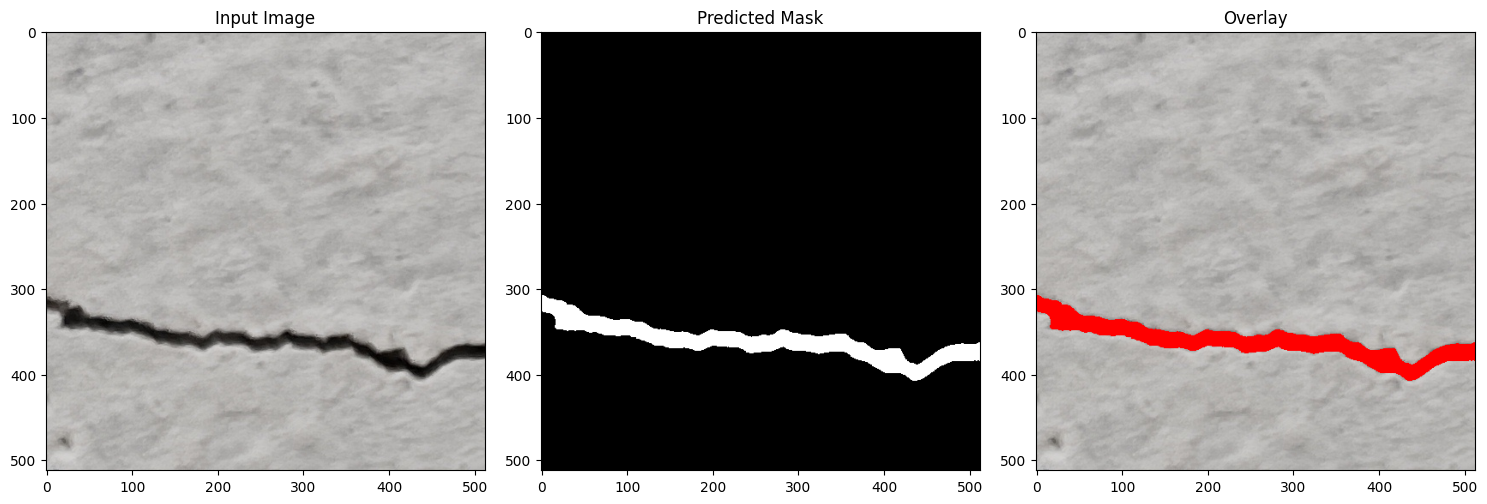

In [4]:
img_filename = '2_18.jpg'
img_addr = os.path.join('image', img_filename)

img = np.array(Image.open(img_addr).convert("RGB"))

# transform = A.Compose([
#     A.Resize(height=hyper_params["image_height"], width=hyper_params["image_width"]),
# ])
# augmentations = transform(image=img)
# img_tensor = augmentations["image"].unsqueeze(0).to(device)  # Shape: [1, 3, H, W]
img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0  # [C, H, W]
img_tensor = img_tensor.unsqueeze(0).to(device)  # Shape: [1, 3, H, W]
print(img_tensor.shape, img_tensor.dtype)  # e.g., torch.Size([3, 512, 512]) torch.float32

# ======= 模型推理 =======
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    output = torch.sigmoid(output)
    output = output.detach().cpu().numpy()
    output_binary = np.where(output >= 0.5, 1, 0)

# ======= 后处理 =======
output = output_binary.transpose(0, 2, 3, 1)  

# ======= 可视化结果 =======
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(img)

plt.subplot(1, 3, 2)
plt.title("Predicted Mask")
plt.imshow(np.squeeze(output), cmap="gray")

plt.subplot(1, 3, 3)
plt.title("Overlay")
overlay = img.copy()
overlay[np.squeeze(output) > 0.5] = [255, 0, 0]  # 红色叠加
plt.imshow(overlay)
plt.tight_layout()
plt.show()

# 图像文件夹推理

In [11]:
dataset_name = "Total"
dataset_dir = os.path.join('image', dataset_name)
output_folder = os.path.join("outputs/Inferences", dataset_name)
picture_names =  os.listdir(dataset_dir)

model.eval()
for img_filename in picture_names:

    img_addr = os.path.join(dataset_dir, img_filename)
    img = np.array(Image.open(img_addr).convert("RGB"))
    img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0  # [C, H, W]
    img_tensor = img_tensor.unsqueeze(0).to(device)  # Shape: [1, 3, H, W]

    with torch.no_grad():
        output = model(img_tensor)
        output = torch.sigmoid(output)
        output = output.detach().cpu().numpy()
        thresh = 0.5
        output_binary = np.where(output >= thresh, 1, 0)

    # ======= 后处理 =======
    output = output_binary.transpose(0, 2, 3, 1)  

    # 保存掩码图像
    save_name = os.path.splitext(img_filename)[0] + "_mask.png"
    save_path = os.path.join(output_folder, save_name)
    # 确保保存目录存在
    os.makedirs(output_folder, exist_ok=True)
    # 保存掩码图像
    mask_img = Image.fromarray((output.squeeze() * 255).astype(np.uint8))
    mask_img.save(save_path)

print(f"\n✅ 所有mask已保存至: {output_folder}")


✅ 所有mask已保存至: outputs/Inferences/Total
